# 5. Multi-Head Attention

**Цель:** Расширить Scaled Dot-Product Attention до многоголового внимания — ключевого компонента трансформеров.

---

In [1]:
# Настройка логирования и импорт библиотек для
# демонстрации механизма Multi-Head Attention.
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("multihead")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Используем MPS (Metal) на Apple Silicon, если доступно.
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)


2026-06-01 00:23:43,778 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data


2026-06-01 00:23:43,788 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:23:43,794 [DEBUG] matplotlib: interactive is False


2026-06-01 00:23:43,795 [DEBUG] matplotlib: platform is darwin


2026-06-01 00:23:43,824 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:23:43,827 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json


2026-06-01 00:23:43,961 [INFO] multihead: Используем устройство: mps


## 5.1 Идея Multi-Head Attention

**Проблема одного внимания:** Одна матрица внимания — один паттерн взаимодействия между токенами.

**Идея:** Использовать h разных "голов" внимания, каждая со своими проекциями Q, K, V:
- Разные головы учат разные типы отношений (синтаксические, семантические, позиционные)
- Каждая голова работает в подпространстве меньшей размерности: d_k = d_model / h
- Результаты конкатенируются и проецируются обратно в d_model

**Формула:**
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W_O$$
$$\text{head}_i = \text{Attention}(QW_Q^i, KW_K^i, VW_V^i)$$

In [2]:
log.debug("Implementing MultiHeadAttention class")

class MultiHeadAttention(nn.Module):
    """Multi-Head Attention с нуля."""
    
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        # d_model обязан делиться на n_heads — иначе split/combine не сработает.
        assert d_model % n_heads == 0, f"d_model ({d_model}) must be divisible by n_heads ({n_heads})"
        
        self.d_model = d_model
        self.n_heads = n_heads
        # d_k = d_model // n_heads: каждая голова работает в подпространстве
        # меньшей размерности. Это позволяет всем головам работать параллельно,
        # не увеличивая суммарное количество параметров и не меняя сложность O(n^2).
        self.d_k = d_model // n_heads
        
        # W_Q, W_K, W_V: три отдельные матрицы d_model × d_model (bias=False).
        # Каждая проецирует входные токены в пространства Query, Key, Value.
        # После проекции результат делится на n_heads срезов размерности d_k —
        # каждая голова получает свою версию Q, K, V. Раздельные W дают
        # каждой голове возможность учить разные паттерны внимания.
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        
        # W_O: финальная проекция d_model → d_model. Смешивает информацию
        # от всех голов обратно в единое представление. Без W_O головы
        # работали бы изолированно, и модель не могла бы комбинировать их выходы.
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout)
        log.debug("MultiHeadAttention: d_model=%d, n_heads=%d, d_k=%d", d_model, n_heads, self.d_k)
    
    def _split_heads(self, x):
        """(batch, seq_len, d_model) -> (batch, n_heads, seq_len, d_k)"""
        batch, seq_len, _ = x.shape
        # view: (batch, seq_len, d_model) -> (batch, seq_len, n_heads, d_k)
        # Группируем d_model в (n_heads, d_k), не перемешивая данные.
        x = x.view(batch, seq_len, self.n_heads, self.d_k)
        # transpose: (batch, seq_len, n_heads, d_k) -> (batch, n_heads, seq_len, d_k)
        # Меняем местами оси seq_len и n_heads, чтобы голова-измерение шла первой.
        # Это позволяет вычислять Scaled Dot-Product Attention параллельно
        # по всем головам через один matmul: Q @ K^T с batch-измерением n_heads.
        return x.transpose(1, 2)  # (batch, n_heads, seq_len, d_k)
    
    def _combine_heads(self, x):
        """(batch, n_heads, seq_len, d_k) -> (batch, seq_len, d_model)"""
        batch, _, seq_len, _ = x.shape
        # Обратная операция к _split_heads:
        # transpose: (batch, n_heads, seq_len, d_k) -> (batch, seq_len, n_heads, d_k)
        # contiguous() нужен после transpose, чтобы view мог перестроить память.
        x = x.transpose(1, 2).contiguous()  # (batch, seq_len, n_heads, d_k)
        # view: (batch, seq_len, n_heads, d_k) -> (batch, seq_len, d_model)
        # Сливаем n_heads и d_k обратно в d_model, восстанавливая исходную размерность.
        return x.view(batch, seq_len, self.d_model)
    
    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q, K, V: (batch, seq_len, d_model)
            mask: (batch, seq_len) — padding mask
        Returns:
            output: (batch, seq_len, d_model)
            attention_weights: (batch, n_heads, seq_len, seq_len)
        """
        batch = Q.size(0)
        
        # 1. Линейные проекции Q, K, V: d_model -> d_model.
        # Каждая матрица W учит, как "спрашивать" (Q), "отвечать" (K)
        # и "передавать информацию" (V) для каждого токена.
        Q = self.W_Q(Q)
        K = self.W_K(K)
        V = self.W_V(V)
        log.debug("After projection shapes: Q=%s, K=%s, V=%s", Q.shape, K.shape, V.shape)
        
        # 2. Разделение на головы: d_model -> n_heads × d_k.
        # Каждая голова получит свой срез размерности d_k для Q, K, V.
        Q = self._split_heads(Q)  # (batch, n_heads, seq_len, d_k)
        K = self._split_heads(K)
        V = self._split_heads(V)
        log.debug("After split: Q=%s, K=%s, V=%s", Q.shape, K.shape, V.shape)
        
        # 3. Scaled Dot-Product Attention для каждой головы параллельно.
        # scores = Q @ K^T / sqrt(d_k) — все головы считаются в одном matmul.
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Маскировка: padding-токены получают -inf, чтобы softmax дал им 0.
        if mask is not None:
            # mask: (batch, seq_len) -> (batch, 1, 1, seq_len)
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Взвешенная сумма значений: (batch, n_heads, seq_len, d_k)
        output = torch.matmul(attention_weights, V)
        log.debug("Per-head output shape: %s", output.shape)
        
        # 4. Объединение голов: (batch, n_heads, seq_len, d_k) -> (batch, seq_len, d_model)
        # Обратная операция к _split_heads — сливаем все головы обратно.
        output = self._combine_heads(output)  # (batch, seq_len, d_model)
        
        # 5. Финальная проекция W_O: смешивает информацию от всех голов.
        output = self.W_O(output)
        log.debug("Final output shape: %s", output.shape)
        
        return output, attention_weights


2026-06-01 00:23:43,973 [DEBUG] multihead: Implementing MultiHeadAttention class


## Формула Multi-Head Attention

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

Каждая голова head_i работает в подпространстве размерности d_k = d_{\text{model}} / h.
Результаты всех голов конкатенируются и проецируются обратно через W^O.


## Что дают разные головы: анализ на примере

Разные головы внимания могут изучать разные типы зависимостей между токенами:

- **Позиционные отношения:** одна голова может фокусироваться на соседних токенах (локальный контекст)
- **Синтаксические отношения:** другая голова — на грамматических связях (подлежащее — сказуемое, аргументы глагола)
- **Семантические отношения:** третья голова — на семантической близости (синонимы, тематически связанные слова)

Каждая голова видит ту же последовательность, но через свою часть проекционных матриц,
поэтому может выделить разные паттерны. В совокупности головы дают богатое многогранное представление входных данных.

На практике в обученных трансформерах (BERT, GPT) разные головы действительно
специализируются: одни отслеживают пунктуацию, другие — синтаксические деревья,
третьи — анафору и кореференцию.


## Параметры: $W_Q$, $W_K$, $W_V$, $W_O$ — линейные проекции

| Матрица | Размерность | Назначение |
|---------|------------|------------|
| $W_Q$ | $d_{\text{model}} \times d_{\text{model}}$ | Проецирует вход в пространство **запросов** (Query) |
| $W_K$ | $d_{\text{model}} \times d_{\text{model}}$ | Проецирует вход в пространство **ключей** (Key) |
| $W_V$ | $d_{\text{model}} \times d_{\text{model}}$ | Проецирует вход в пространство **значений** (Value) |
| $W_O$ | $d_{\text{model}} \times d_{\text{model}}$ | Проецирует конкатенацию голов обратно в $d_{\text{model}}$ |

**Сколько параметров?** Каждая матрица — `nn.Linear(d_model, d_model, bias=False)`, то есть $d_{\text{model}}^2$ параметров.
Всего $4 \times d_{\text{model}}^2$. Например, при $d_{\text{model}} = 512$ это $4 \times 262\,144 = 1\,048\,576$ параметров (без учёта остальных слоёв).

**Что делает каждая проекция?**
- $W_Q$: определяет, *на что* смотрит каждый токен (какой запрос он формирует)
- $W_K$: определяет, *насколько токен виден* другим (какой ключ он предоставляет)
- $W_V$: определяет, *какую информацию* токен передаёт, если на него обратили внимание
- $W_O$: смешивает информацию от всех голов в единое представление

Разделение на $W_Q$, $W_K$, $W_V$ позволяет модели независимо учить,
как "спрашивать", "отвечать" и "передавать".
Без $W_O$ выходы голов оставались бы изолированными — финальная проекция
обеспечивает взаимодействие между головами.


In [3]:
log.debug("Testing MultiHeadAttention forward pass")

# d_model=64, n_heads=8 => d_k=8 на голову.
# Каждая из 8 голов работает в 8-мерном подпространстве.
d_model, n_heads, seq_len, batch = 64, 8, 10, 4
mha = MultiHeadAttention(d_model, n_heads).to(device)

# В общем случае Q, K, V могут быть разными (cross-attention).
# Здесь используем разные случайные тензоры для демонстрации.
Q = torch.randn(batch, seq_len, d_model, device=device)
K = torch.randn(batch, seq_len, d_model, device=device)
V = torch.randn(batch, seq_len, d_model, device=device)

output, attn_weights = mha(Q, K, V)

# Проверяем, что размерности сошлись.
# batch и seq_len сохраняются, d_model восстанавливается после W_O.
print(f"Input shape:        {Q.shape}")
print(f"Output shape:       {output.shape}")
# attn_weights хранит карты внимания для каждой головы: (batch, n_heads, seq_len, seq_len).
print(f"Attention weights:  {attn_weights.shape}")
print(f"Number of heads:    {n_heads}")
print(f"d_k per head:       {d_model // n_heads}")
# Параметры: 4 матрицы d_model × d_model = 4 × 64² = 16384.
print(f"Parameters:         {sum(p.numel() for p in mha.parameters()):,}")
log.info("MultiHeadAttention forward pass OK, params=%d", sum(p.numel() for p in mha.parameters()))


2026-06-01 00:23:43,980 [DEBUG] multihead: Testing MultiHeadAttention forward pass


2026-06-01 00:23:43,981 [DEBUG] multihead: MultiHeadAttention: d_model=64, n_heads=8, d_k=8


2026-06-01 00:23:44,171 [DEBUG] multihead: After projection shapes: Q=torch.Size([4, 10, 64]), K=torch.Size([4, 10, 64]), V=torch.Size([4, 10, 64])


2026-06-01 00:23:44,172 [DEBUG] multihead: After split: Q=torch.Size([4, 8, 10, 8]), K=torch.Size([4, 8, 10, 8]), V=torch.Size([4, 8, 10, 8])


2026-06-01 00:23:44,522 [DEBUG] multihead: Per-head output shape: torch.Size([4, 8, 10, 8])


2026-06-01 00:23:44,524 [DEBUG] multihead: Final output shape: torch.Size([4, 10, 64])


2026-06-01 00:23:44,524 [INFO] multihead: MultiHeadAttention forward pass OK, params=16384


Input shape:        torch.Size([4, 10, 64])
Output shape:       torch.Size([4, 10, 64])
Attention weights:  torch.Size([4, 8, 10, 10])
Number of heads:    8
d_k per head:       8
Parameters:         16,384


## 5.2 Визуализация: что учат разные головы?

Каждая голова может фокусироваться на разных аспектах взаимодействия токенов.

2026-06-01 00:23:44,530 [DEBUG] multihead: Visualizing attention patterns across heads


2026-06-01 00:23:44,538 [DEBUG] multihead: MultiHeadAttention: d_model=32, n_heads=4, d_k=8


2026-06-01 00:23:44,540 [DEBUG] multihead: After projection shapes: Q=torch.Size([1, 8, 32]), K=torch.Size([1, 8, 32]), V=torch.Size([1, 8, 32])


2026-06-01 00:23:44,540 [DEBUG] multihead: After split: Q=torch.Size([1, 4, 8, 8]), K=torch.Size([1, 4, 8, 8]), V=torch.Size([1, 4, 8, 8])


2026-06-01 00:23:44,541 [DEBUG] multihead: Per-head output shape: torch.Size([1, 4, 8, 8])


...

2026-06-01 00:23:45,384 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansBuhid-Regular.ttf', name='Noto Sans Buhid', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:45,385 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Phosphate.ttc', name='Phosphate', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:45,385 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansInscriptionalParthian-Regular.ttf', name='Noto Sans Inscriptional Parthian', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:45,385 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXNonUni.otf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:45,386 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=14.0 to DejaVu Sans ('/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


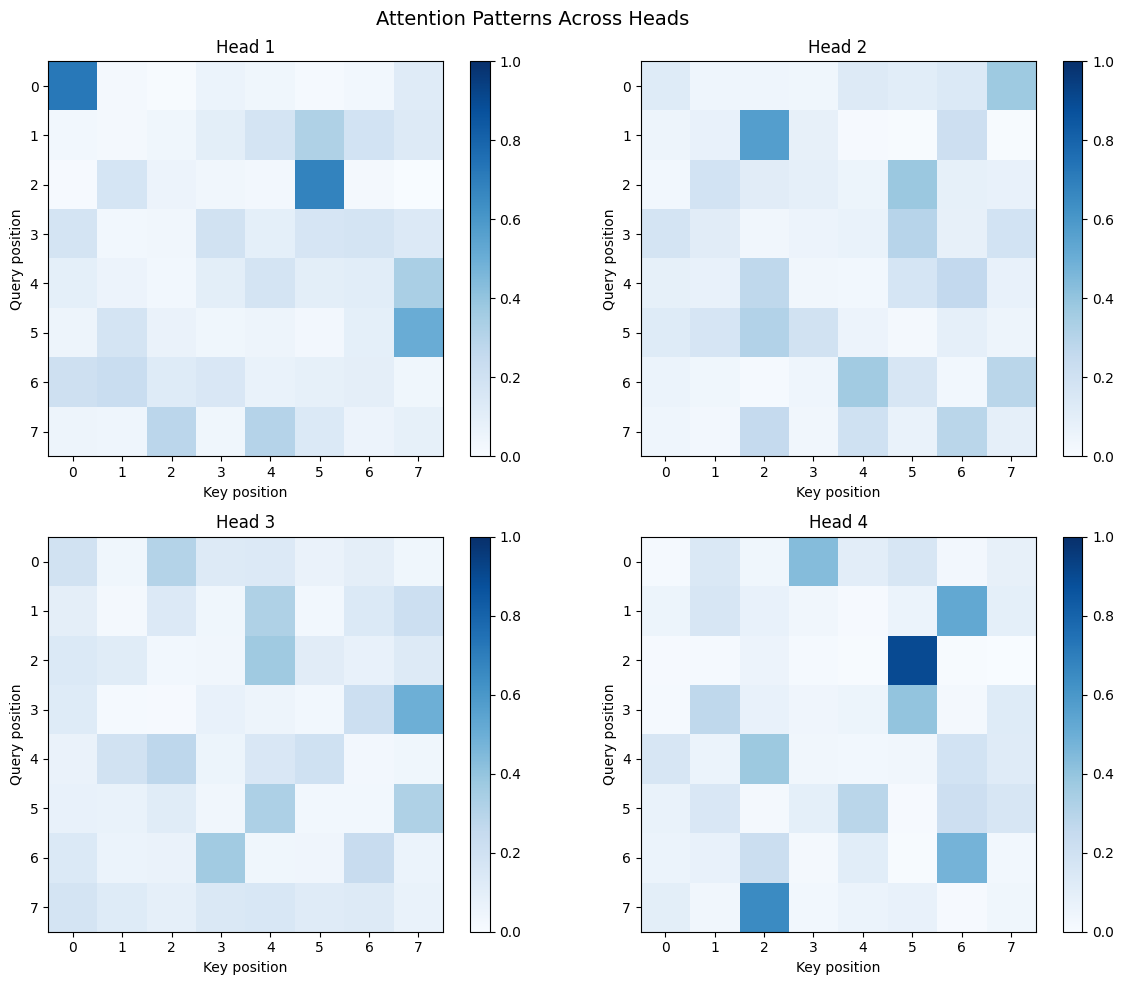

2026-06-01 00:23:45,657 [INFO] multihead: Multi-head attention patterns visualized


In [4]:
log.debug("Visualizing attention patterns across heads")

torch.manual_seed(42)
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

# Используем разные случайные данные, чтобы головы давали разные паттерны.
# На практике разные головы учат разные типы отношений (позиционные,
# синтаксические, семантические) благодаря разной инициализации W_Q, W_K, W_V
# и разным градиентам при обучении.
Q = torch.randn(1, 8, d_model) * 2
K = torch.randn(1, 8, d_model) * 2
V = torch.randn(1, 8, d_model) * 2

with torch.no_grad():
    output, attn_weights = mha(Q, K, V)

# Визуализируем карты внимания для каждой из 4 голов.
# Каждая голова имеет свой паттерн — одни фокусируются на диагонали (сама на себя),
# другие — на соседних токенах, третьи — на удалённых.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(attn_weights[0, i].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {i+1}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Attention Patterns Across Heads', fontsize=14)
plt.tight_layout()
plt.show()
log.info("Multi-head attention patterns visualized")


## 5.3 Исследование: влияние числа голов

Проверим, как количество голов влияет на количество параметров и скорость.

2026-06-01 00:23:45,667 [DEBUG] multihead: Analyzing impact of number of heads


2026-06-01 00:23:45,670 [DEBUG] multihead: MultiHeadAttention: d_model=256, n_heads=1, d_k=256


2026-06-01 00:23:45,749 [DEBUG] multihead: After projection shapes: Q=torch.Size([8, 64, 256]), K=torch.Size([8, 64, 256]), V=torch.Size([8, 64, 256])


2026-06-01 00:23:45,750 [DEBUG] multihead: After split: Q=torch.Size([8, 1, 64, 256]), K=torch.Size([8, 1, 64, 256]), V=torch.Size([8, 1, 64, 256])


2026-06-01 00:23:45,863 [DEBUG] multihead: Per-head output shape: torch.Size([8, 1, 64, 256])


...

2026-06-01 00:23:47,069 [DEBUG] multihead: After projection shapes: Q=torch.Size([8, 64, 256]), K=torch.Size([8, 64, 256]), V=torch.Size([8, 64, 256])


2026-06-01 00:23:47,069 [DEBUG] multihead: After split: Q=torch.Size([8, 32, 64, 8]), K=torch.Size([8, 32, 64, 8]), V=torch.Size([8, 32, 64, 8])


2026-06-01 00:23:47,070 [DEBUG] multihead: Per-head output shape: torch.Size([8, 32, 64, 8])


2026-06-01 00:23:47,070 [DEBUG] multihead: Final output shape: torch.Size([8, 64, 256])


2026-06-01 00:23:47,072 [INFO] multihead: n_heads=32, params=262144, time=1.882ms


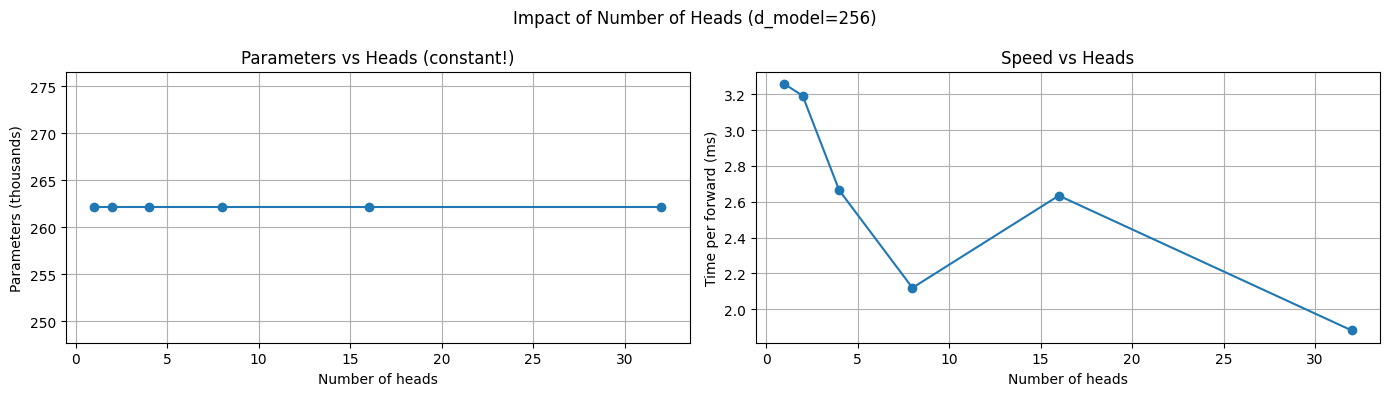

2026-06-01 00:23:47,197 [INFO] multihead: Head impact analysis complete


In [5]:
log.debug("Analyzing impact of number of heads")

import time

d_model = 256
# Меняем количество голов при фиксированном d_model.
# Количество параметров НЕ меняется: 4 × d_model² всегда.
# Меняется только d_k = d_model / n_heads — размер подпространства каждой головы.
head_options = [1, 2, 4, 8, 16, 32]
batch, seq_len = 8, 64

results = []
for n_heads in head_options:
    mha = MultiHeadAttention(d_model, n_heads).to(device)
    # Все варианты имеют одинаковое число параметров:
    # 4 матрицы d_model×d_model при bias=False.
    params = sum(p.numel() for p in mha.parameters())
    
    Q = torch.randn(batch, seq_len, d_model, device=device)
    K = torch.randn(batch, seq_len, d_model, device=device)
    V = torch.randn(batch, seq_len, d_model, device=device)
    
    # Warmup (разогрев)
    for _ in range(5):
        mha(Q, K, V)
    if device.type == 'mps':
        torch.mps.synchronize()
    
    start = time.perf_counter()
    for _ in range(50):
        mha(Q, K, V)
    if device.type == 'mps':
        torch.mps.synchronize()
    elapsed = (time.perf_counter() - start) / 50
    
    results.append((n_heads, params, elapsed))
    log.info("n_heads=%d, params=%d, time=%.3fms", n_heads, params, elapsed*1000)

n_heads_arr, params_arr, times_arr = zip(*results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(n_heads_arr, [p/1000 for p in params_arr], 'o-')
axes[0].set_xlabel('Number of heads')
axes[0].set_ylabel('Parameters (thousands)')
# Параметры действительно не зависят от n_heads — линия горизонтальна.
axes[0].set_title('Parameters vs Heads (constant!)')
axes[0].grid(True)

axes[1].plot(n_heads_arr, [t*1000 for t in times_arr], 'o-')
axes[1].set_xlabel('Number of heads')
axes[1].set_ylabel('Time per forward (ms)')
# Время может расти с числом голов из-за накладных расходов на split/combine.
axes[1].set_title('Speed vs Heads')
axes[1].grid(True)

plt.suptitle(f'Impact of Number of Heads (d_model={d_model})')
plt.tight_layout()
plt.show()
log.info("Head impact analysis complete")


## 5.4 Self-Attention: Q=K=V

В энкодере трансформера используется Self-Attention: Q, K, V берутся из одного источника.

In [6]:
log.debug("Demonstrating self-attention")

d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

# Self-attention: Q = K = V = x — один и тот же вход.
# Каждый токен "смотрит" на все токены той же последовательности.
# Так работает энкодер Transformer: каждый слой self-attention
# обновляет представления токенов с учётом контекста.
x = torch.randn(1, 6, d_model)
output, attn_weights = mha(x, x, x)

print(f"Self-attention input:  {x.shape}")
print(f"Self-attention output: {output.shape}")
print(f"Attention:             {attn_weights.shape}")

# Покажем, что диагональ внимания обычно доминирует (токен "смотрит" на себя).
# Это ожидаемо: токену проще всего "узнавать" самого себя в пространстве Key/Query.
diag_mean = attn_weights[:, :, range(6), range(6)].mean().item()
print(f"Mean diagonal weight: {diag_mean:.3f} (out of 1.0 per row)")
log.info("Self-attention diagonal dominance: %.3f", diag_mean)


2026-06-01 00:23:47,202 [DEBUG] multihead: Demonstrating self-attention


2026-06-01 00:23:47,203 [DEBUG] multihead: MultiHeadAttention: d_model=32, n_heads=4, d_k=8


2026-06-01 00:23:47,203 [DEBUG] multihead: After projection shapes: Q=torch.Size([1, 6, 32]), K=torch.Size([1, 6, 32]), V=torch.Size([1, 6, 32])


2026-06-01 00:23:47,204 [DEBUG] multihead: After split: Q=torch.Size([1, 4, 6, 8]), K=torch.Size([1, 4, 6, 8]), V=torch.Size([1, 4, 6, 8])


2026-06-01 00:23:47,205 [DEBUG] multihead: Per-head output shape: torch.Size([1, 4, 6, 8])


2026-06-01 00:23:47,205 [DEBUG] multihead: Final output shape: torch.Size([1, 6, 32])


2026-06-01 00:23:47,206 [INFO] multihead: Self-attention diagonal dominance: 0.164


Self-attention input:  torch.Size([1, 6, 32])
Self-attention output: torch.Size([1, 6, 32])
Attention:             torch.Size([1, 4, 6, 6])
Mean diagonal weight: 0.164 (out of 1.0 per row)


## 5.5 Cross-Attention: Q из одного источника, K, V из другого

В декодере трансформера используется Cross-Attention: Q от декодера, K, V от энкодера.

2026-06-01 00:23:47,211 [DEBUG] multihead: Demonstrating cross-attention


2026-06-01 00:23:47,212 [DEBUG] multihead: MultiHeadAttention: d_model=32, n_heads=4, d_k=8


2026-06-01 00:23:47,213 [DEBUG] multihead: After projection shapes: Q=torch.Size([1, 4, 32]), K=torch.Size([1, 8, 32]), V=torch.Size([1, 8, 32])


2026-06-01 00:23:47,213 [DEBUG] multihead: After split: Q=torch.Size([1, 4, 4, 8]), K=torch.Size([1, 4, 8, 8]), V=torch.Size([1, 4, 8, 8])


2026-06-01 00:23:47,214 [DEBUG] multihead: Per-head output shape: torch.Size([1, 4, 4, 8])


...

2026-06-01 00:23:47,238 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112ce08e0>


2026-06-01 00:23:47,246 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112d22f40>


2026-06-01 00:23:47,253 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112d6b970>


2026-06-01 00:23:47,260 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x112db1430>


Decoder (Q) shape:   torch.Size([1, 4, 32])
Encoder (K, V) shape:torch.Size([1, 8, 32])
Cross-attention output:torch.Size([1, 4, 32])
Attention:             torch.Size([1, 4, 4, 8])


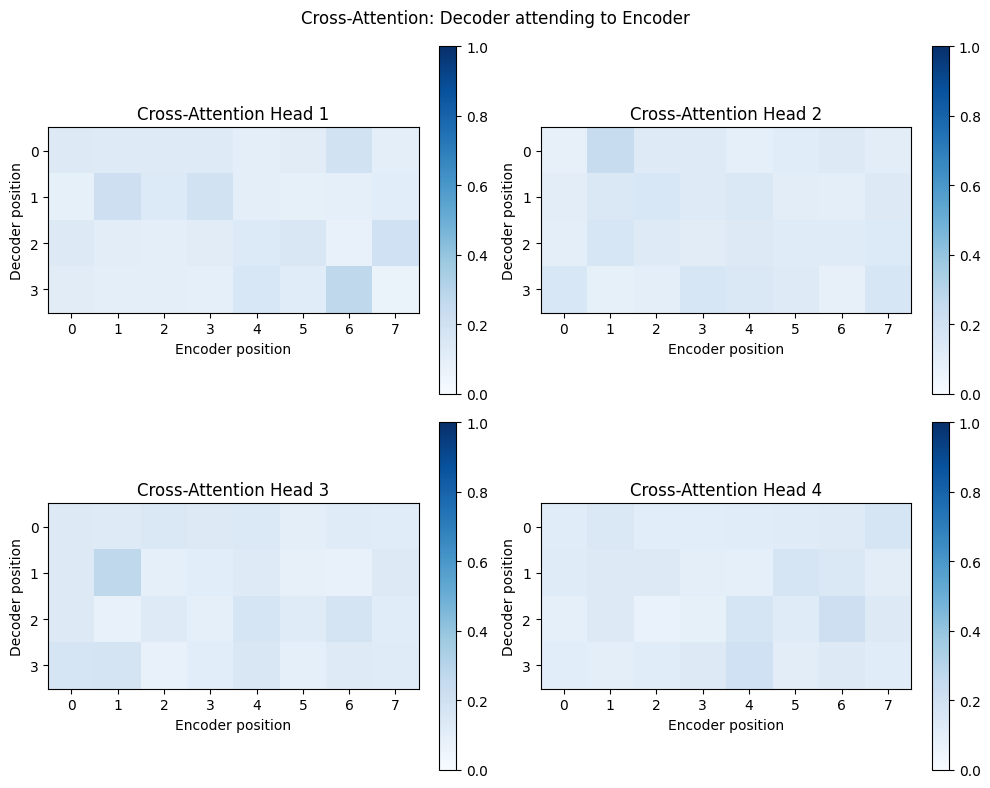

2026-06-01 00:23:47,485 [INFO] multihead: Cross-attention demonstration complete


In [7]:
log.debug("Demonstrating cross-attention")

d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

# Cross-attention (перекрёстное внимание): Q из decoder, K, V из encoder.
# Позволяет декодеру "заглядывать" во входную последовательность.
# Количество ключей/значений (seq_len энкодера) может отличаться
# от количества запросов (seq_len декодера).
decoder_output = torch.randn(1, 4, d_model)  # 4 токена в декодере
encoder_output = torch.randn(1, 8, d_model)  # 8 токенов в энкодере

output, attn_weights = mha(decoder_output, encoder_output, encoder_output)

print(f"Decoder (Q) shape:   {decoder_output.shape}")
print(f"Encoder (K, V) shape:{encoder_output.shape}")
print(f"Cross-attention output:{output.shape}")
# Выход имеет seq_len декодера (4), а attention weights — (4, 8).
print(f"Attention:             {attn_weights.shape}")

# Визуализация cross-attention
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(attn_weights[0, i].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Cross-Attention Head {i+1}')
    ax.set_xlabel('Encoder position')
    ax.set_ylabel('Decoder position')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Cross-Attention: Decoder attending to Encoder')
plt.tight_layout()
plt.show()
log.info("Cross-attention demonstration complete")


In [8]:
print("=== Multi-Head Attention complete ===")
print("Topics covered:")
print("  - MultiHeadAttention class from scratch")
print("  - Split/combine heads mechanism")
# Разные головы учат разные паттерны внимания благодаря разным проекциям W_Q, W_K, W_V.
print("  - Visualization of different head patterns")
# Количество параметров не зависит от числа голов — 4 × d_model².
print("  - Impact of number of heads on params and speed")
print("  - Self-Attention (Q=K=V) vs Cross-Attention")
print("  - Padding mask for multi-head attention")
log.info("MultiHead attention notebook complete")


2026-06-01 00:23:47,488 [INFO] multihead: MultiHead attention notebook complete


=== Multi-Head Attention complete ===
Topics covered:
  - MultiHeadAttention class from scratch
  - Split/combine heads mechanism
  - Visualization of different head patterns
  - Impact of number of heads on params and speed
  - Self-Attention (Q=K=V) vs Cross-Attention
  - Padding mask for multi-head attention


📚 **Полезные ссылки:**
- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)
